# PROJETO INTEGRADOR - Marketplace - AWS


-- introdução:

 este é um projeto integrador feito em colaboração com a faculdade SENAI e a AWS
e blabla..

-- objetivo:

 corrigir a cagada do usuário(avaliações e comentários redartários)


# anotações 26/05

Estas são anotações feitas após review com FELIPE sobre o projeto integrador e o prazo de entrega adiantado para 03/06, após esclarecimentos de ideias sobre o projeto:



- merge em todas as tabelas -  irá corrigir parte da tipagem automaticamente.

- faça uma função/FOR para corrigir o restante da tipagem.

- aplique uma solução para geolocalização - não tem chave primaria.

- antes de tratar as colunas relacionadas a avaliações, concatene-a(a concatenação foi feita, e os nulos foram removidos em um datafrae separado).

- ***IMPORTANTE : O foco principal do projeto é DF_AVALIACOES - verificar a coerência dos comentarios com a nota do usuario***.

- Após concatenar e tratar os dados, deve ser feito a comparação com as bibliotecas de analise(RECOMENDADO APLICAR ANÁLISE FINAL E CRIAR COLUNAS DE ANALISE_SENTIMENTO SOMENTE APÓS ISSO).

- Faça comparaçoes entre Vader e LeIA: elas são coerentes com review score?.

- Para Cada gráfico elabore uma DISCUSSÃO(a discussão deve ser tanto descritiva como qualitativa).

- Vader e leIA: compare as análises de ambas em comentários maiores/menores(interessante para averiguar defeitos da Vader(gráfico de Boxplot)).

- linhas df_avaliacoes - 33115, 28675, 19539, 36214, 17051, 4166, 8433: comentários excentricos, emojis atrapalhando análise, incoerencia na avaliação, tudo de ruim.

- VADER é mt ruim - esculache-a, justifique com as análises

- INTERESSANTE: gráfico distribuição de pontuacao_sentimento de VADER e leIA.

- INTERESSANTE: matriz relacionando review score com analise_sentimento.

- pesquisar sobre dicionário de palavras: cada palavra/emoji vale uma porcentagem da pontuacao_sentimento, verifique quais palavras estão problematizando a análise

- eficiencia de leIA para análise chega próximo á 62% de acerto(cocô do Vader: 15% ~ 18%), não vou elaborar.

- transforms: é o melhor de todos, vamos usar? sim, em caso de dúvida, procure o Felipe.

- Felipe vai reservar o final de semana para acompanhar os repositorios do projeto integrador, em qualquer caso contate-o se houver complicações.

## IMPORTANDO BIBLIOTECAS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib . pyplot as plt
import seaborn as sns

In [ ]:
#importando arquivo.csv diretamente do google drive
from google.colab import drive
drive.mount('/content/drive')

df_pedido = pd.read_csv("/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/pedidos.csv")
df_produtos = pd.read_csv("/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/produtos.csv")
df_geolocalizacao = pd.read_csv("/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/geolocalizacao.csv")
df_avaliacoes = pd.read_csv("/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/avaliacoes.csv")
df_pagamentos = pd.read_csv("/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/pagamentos.csv")
df_vendedores = pd.read_csv("/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/vendedores.csv")
df_tabela_auxiliar = pd.read_csv("/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/tabela_auxiliar.csv")
df_itens = pd.read_csv("/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/itens_pedidos.csv")
df_clientes = pd.read_csv("/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/clientes.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def analise():

  # menu interativo
  print('df_pedido - 1')
  print('df_produtos - 2')
  print('df_geolocalizacao - 3')
  print('df_avaliacoes - 4')
  print('df_pagamentos - 5')
  print('df_vendedores - 6')
  print('df_tabela_auxiliar - 7')
  print('df_itens - 8')
  print('df_clientes - 9')
  print('-'*50)
  print('Qual entidade vamos acessar agora?')
  dataframe_name = input(('digite o nome referente ao Dataframe:'))

  dataframes = [
      'df_pedido', 'df_produtos', 'df_geolocalizacao',
      'df_avaliacoes', 'df_pagamentos', 'df_vendedores',
      'df_tabela_auxiliar', 'df_itens', 'df_clientes'
  ]

  if dataframe_name in dataframes:
    try:
      dataframe_obj = globals()[dataframe_name]
      print(f"\n--- Informações de {dataframe_name} ---")
      display(dataframe_obj.info())

      print(f"\n--- Primeiras 25 linhas de {dataframe_name} ---")
      display(dataframe_obj.head(25))

      print(f"\n--- Contagem de valores nulos em {dataframe_name} ---")
      display(dataframe_obj.isnull().sum())

      print(f"\n--- Contagem total de valores (não nulos) em {dataframe_name} ---")
      display(dataframe_obj.count())

      print(f"\n--- Descrição estatística de {dataframe_name} ---")
      display(dataframe_obj.describe(include='all'))

    except KeyError:
      print(f"Erro: O DataFrame '{dataframe_name}' não foi encontrado ou não está definido.")
    except Exception as e:
      print(f"Ocorreu um erro ao processar o DataFrame {dataframe_name}: {e}")
  else:
      print('Erro: DataFrame não identificado ou inválido.')

In [ ]:
# analise()

In [ ]:
def analise_info():

  dataframes = [
      'df_pedido', 'df_produtos', 'df_geolocalizacao',
      'df_avaliacoes', 'df_pagamentos', 'df_vendedores',
      'df_tabela_auxiliar', 'df_itens', 'df_clientes'
  ]

  for dataframe_name in dataframes:
    try:
      dataframe_obj = globals()[dataframe_name]
      print(f"\n--- Informações de {dataframe_name} ---")
      dataframe_obj.info()

    except KeyError:
      print(f"Erro: O DataFrame '{dataframe_name}' não foi encontrado ou não está definido.")
    except Exception as e:
      print(f"Ocorreu um erro ao processar o DataFrame {dataframe_name}: {e}")

In [ ]:
analise_info()


--- Informações de df_pedido ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

--- Informações de df_produtos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                

### TESTANDO Vader, leIA, Textblob e Transforms - machine learning focada em analisar sentimento de textos

## leIA - a melhor a biblioteca para análise sentimento

In [ ]:
!pip install pandas leia-br
!pip install LeIA

In [ ]:
from LeIA import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

df_avaliacoes['review_comment_message'] = (
  df_avaliacoes['review_comment_message'].fillna('')
)

def calcular_sentimento(texto):
  if texto.strip() == '':
    return 0.0
  return sid.polarity_scores(texto)['compound']

df_avaliacoes['pontuacao_sentimento'] = (df_avaliacoes['review_comment_message'].apply(calcular_sentimento)
)

def map_score_to_stars(score):
    stars = (score + 1) / 2 * 4 + 1
    return int(np.clip(round(stars), 1, 5))

df_avaliacoes['estrelas_sentimento'] = df_avaliacoes['pontuacao_sentimento'].apply(map_score_to_stars)
df_avaliacoes['review_message_length'] = df_avaliacoes['review_comment_message'].str.len()



display(df_avaliacoes[
    ['review_comment_message', 'review_message_length', 'pontuacao_sentimento','estrelas_sentimento','review_score']
    ].head(50))

,review_comment_message,review_message_length,pontuacao_sentimento,estrelas_sentimento,review_score
0,,0,0.0000,3,4
1,,0,0.0000,3,5
2,,0,0.0000,3,5
3,Recebi bem antes do prazo estipulado.,37,0.2732,4,5
4,Parabéns lojas lannister adorei comprar pela I...,100,0.9413,5,5
5,,0,0.0000,3,1
6,,0,0.0000,3,5
7,,0,0.0000,3,5
8,,0,0.0000,3,5
9,aparelho eficiente. no site a marca do aparelh...,174,0.4215,4,4


## VADER - biblioteca original utilizada na leIA

In [ ]:
!pip install vaderSentiment

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

df_avaliacoes['review_comment_message'] = (
df_avaliacoes['review_comment_message'].fillna('')
)

def calcular_sentimento(texto):
  if texto.strip() == '':
    return 0.0
  return vader.polarity_scores(texto)['compound']

df_avaliacoes['pontuacao_sentimento_vader'] = (df_avaliacoes['review_comment_message'].apply(calcular_sentimento)
)

def map_score_to_stars(score):
    stars = (score + 1) / 2 * 4 + 1
    return int(np.clip(round(stars), 1, 5))

df_avaliacoes['estrelas_sentimento_vader'] = df_avaliacoes['pontuacao_sentimento_vader'].apply(map_score_to_stars)

display(df_avaliacoes[
    ['review_comment_message', 'review_message_length', 'pontuacao_sentimento_vader','estrelas_sentimento_vader','review_score']
    ].head(50))

,review_comment_message,review_message_length,pontuacao_sentimento_vader,estrelas_sentimento_vader,review_score
0,,0,0.000,3,4
1,,0,0.000,3,5
2,,0,0.000,3,5
3,Recebi bem antes do prazo estipulado.,37,0.000,3,5
4,Parabéns lojas lannister adorei comprar pela I...,100,0.000,3,5
5,,0,0.000,3,1
6,,0,0.000,3,5
7,,0,0.000,3,5
8,,0,0.000,3,5
9,aparelho eficiente. no site a marca do aparelh...,174,-0.296,2,4


## TEXT BLOB - biblioteca de análise de sentimento em Inglês

In [ ]:
# !pip install textblob deep-translator
# !pip install googletrans==4.0.0-rc1

In [ ]:
# SUMA TEXTBLOB E NÃO VOLTE MAIS


# from textblob import TextBlob
# from deep_translator import GoogleTranslator

# translator = GoogleTranslator(source='pt', target='en')

# df_avaliacoes['review_comment_message'] = (
#     df_avaliacoes['review_comment_message'].fillna('')
# )

# def translate_and_analyze_textblob(text):
#     if text.strip() == '':
#         return 0.0 # Neutral sentiment for empty messages
#     try:
#         # Translate to English (TextBlob is optimized for English)
#         translated_text = translator.translate(text)
#         # Get TextBlob polarity score (-1 to 1)
#         return TextBlob(translated_text).sentiment.polarity
#     except Exception as e:
#         print(f"Error translating/analyzing text: {text}. Error: {e}")
#         return 0.0 # Default to neutral if translation fails

# df_avaliacoes['pontuacao_sentimento_textblob'] = (
#     df_avaliacoes['review_comment_message'].apply(translate_and_analyze_textblob)
# )

# def map_score_to_stars(score):
#     # TextBlob polarity ranges from -1 to 1.
#     # Map to 1-5 stars: (score + 1) / 2 converts -1 to 0, 1 to 1.
#     # Then multiply by 4 and add 1 to get 1-5.
#     stars = (score + 1) / 2 * 4 + 1
#     return int(np.clip(round(stars), 1, 5))

# df_avaliacoes['estrelas_sentimento_textblob'] = (
#     df_avaliacoes['pontuacao_sentimento_textblob'].apply(map_score_to_stars)
# )

# display(df_avaliacoes[
#     ['review_comment_message', 'review_message_length', 'pontuacao_sentimento_textblob', 'estrelas_sentimento_textblob', 'review_score']
# ].head(50))

## Verificaçôes alternativas no banco de dados

### exibe avaliacoes com maior Número de Caracteres

In [ ]:
display(df_avaliacoes.sort_values(by='review_message_length', ascending=False)[[
    'review_comment_message', 'review_message_length','pontuacao_sentimento_vader','pontuacao_sentimento',
    'estrelas_sentimento_vader', 'estrelas_sentimento', 'review_score'
]].head(50))

,review_comment_message,review_message_length,pontuacao_sentimento_vader,pontuacao_sentimento,estrelas_sentimento_vader,estrelas_sentimento,review_score
1316,"NÃO RECEBI O PRODUTO, O PRODUTO CONSTA COMO EN...",208,0.0000,-0.9093,3,1,1
10734,Adquiri 2 mochilas pelo site lannister de e pa...,207,0.0000,0.7184,3,4,4
7267,Comprei o produto confiando nas lojas lanniste...,206,-0.2960,0.1779,2,3,1
5223,fiz essa compra pelo baratheon comprei um conj...,205,0.0000,-0.4215,3,2,1
5792,Estou muito insatisfeito com essa loja targary...,204,-0.4724,-0.6981,2,2,1
46535,"Parabéns , ,estou satisfeita com a loja e com ...",204,0.0000,0.8779,3,5,5
84851,"Recebi o produto, mas a embalagem e falta do s...",204,0.0000,-0.6956,3,2,1
91764,"Parabéns ,o produto tira rico da empresa targa...",204,0.0000,0.1027,3,3,5
33455,A EMPRESA FAZ PROPAGANDA ENGANOSA EM SEU SITE....,204,-0.4084,-0.9296,2,1,1
60442,Recebi a mercadoria errada.\r\nComprei o chuve...,204,0.0000,0.2617,3,4,1


### exibindo somente Avaliações que possuam qualquer EMOJI

In [ ]:
import re

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags (iOS)
    "\U00002702-\U000027B0"  # Dingbats
    "\U000024C2-\U0001F251"  # Enclosed CJK Letters and Months, Ideographic Variation Selectors, and other symbols
    "\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
    "\U0001FA00-\U0001FA6F"  # Chess Symbols, Symbols and Pictographs Extended-A
    "\U00002600-\U000026FF"  # Miscellaneous Symbols
    "]+", flags=re.UNICODE
)

def contains_emoji(text):
    if pd.isna(text):
        return False
    return bool(emoji_pattern.search(text))

df_emoji_reviews = df_avaliacoes[df_avaliacoes['review_comment_message'].apply(contains_emoji)]

display(df_emoji_reviews[[
    'review_comment_message', 'review_message_length',
    'estrelas_sentimento', 'review_score'
]].head(100))

,review_comment_message,review_message_length,estrelas_sentimento,review_score
314,Cada vez que compro mais fico satisfeita parab...,90,5,5
544,"Comprei o produto, paguei no boleto e só receb...",128,3,2
566,Perfeitos😁,10,3,5
630,Parabéns 😤 pelo excelente atendimento de quali...,51,5,5
644,"Produto perfeito, entrega rápida. Estou satisf...",59,4,5
...,...,...,...,...
30887,Recebi o produto correto e muito antes do prazo 😍,49,3,5
30969,"Só achei que a tampa deveria ser mais firme, q...",106,3,5
31413,A melhor loja👏👏👏👏😍,18,4,5
31898,👍🏻,2,3,5


## IMPORTANTE - tratamento de comentários nulos e concatenação de titulos com Comentários em df_avaliacoes

aqui neste bloco será feito:

- verificação dos títulos de comentários existentes no Banco
- Criação de um dataframe_alternativo que armazene os valores de título em descrição de comentários nulos
- remoção de registros que possuam descrições de comentários vazios

In [ ]:
# 1. Lista de comentários com descrição vazia mas com títulos de comentário
print("\n--- Comentários com descrição vazia mas com título ---")
filtered_empty_message_with_title = df_avaliacoes[
    (df_avaliacoes['review_comment_message'].fillna('').str.strip() == '') &
    (df_avaliacoes['review_comment_title'].fillna('').str.strip() != '')
]
display(filtered_empty_message_with_title[['review_comment_title', 'review_comment_message', 'review_score']].head())
print(f"Total de comentários com descrição vazia e título: {len(filtered_empty_message_with_title)}")

# 2. Lista de comentários com título e descrição
print("\n--- Comentários com título e descrição ---")
filtered_title_and_message = df_avaliacoes[
    (df_avaliacoes['review_comment_message'].fillna('').str.strip() != '') &
    (df_avaliacoes['review_comment_title'].fillna('').str.strip() != '')
]
display(filtered_title_and_message[['review_comment_title', 'review_comment_message', 'review_score']].head())
print(f"Total de comentários com título e descrição: {len(filtered_title_and_message)}")


total = len(filtered_empty_message_with_title) + len(filtered_title_and_message)

print(f"Total de comentários com título e descrição: {len(filtered_title_and_message)}")


--- Comentários com descrição vazia mas com título ---


,review_comment_title,review_comment_message,review_score
53,Ótimo,,5
104,Não recebi o produto.,,3
220,Entrega antes do previsto,,5
225,Recomendo,,5
495,Ótimo,,5


Total de comentários com descrição vazia e título: 1737

--- Comentários com título e descrição ---


,review_comment_title,review_comment_message,review_score
9,recomendo,aparelho eficiente. no site a marca do aparelh...,4
15,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",5
19,Não chegou meu produto,Péssimo,1
22,Ótimo,Loja nota 10,5
34,Muito bom.,Recebi exatamente o que esperava. As demais en...,4


Total de comentários com título e descrição: 9829


In [ ]:
# Criar um novo DataFrame para armazenar as alterações
df_av_concatenado_sem_nulo = df_avaliacoes.copy()

# Função para concatenar título e mensagem
def concatenar_titulo_mensagem(row):
    title = str(row['review_comment_title']).strip()
    message = str(row['review_comment_message']).strip()

    if title and title != 'nan':  # Check if title is not empty or NaN string
        if message and message != 'nan':  # Check if message is not empty or NaN string
            return f"{title} - {message}"
        else:
            return title
    elif message and message != 'nan':
        return message
    return ''  # Retorna string vazia caso o campo seja vazio ou nulo

# Aplicar a função para atualizar 'review_comment_message'
df_av_concatenado_sem_nulo['review_comment_message'] = df_av_concatenado_sem_nulo.apply(concatenar_titulo_mensagem, axis=1)

# Excluir registros onde 'review_comment_message' ainda está vazio após a concatenação
df_av_concatenado_sem_nulo = df_av_concatenado_sem_nulo[df_av_concatenado_sem_nulo['review_comment_message'] != '']


In [ ]:
import re

# Filtrar mensagens que não são vazias/nulas e que não contêm dígitos
df_av_sem_nulo = df_avaliacoes[
    (df_avaliacoes['review_comment_message'].fillna('').str.strip() != '') &
    (~df_avaliacoes['review_comment_message'].fillna('').str.contains(r'\d', regex=True))
]

display(df_av_sem_nulo.head())

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,pontuacao_sentimento,estrelas_sentimento,review_message_length,pontuacao_sentimento_vader,estrelas_sentimento_vader
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,0.2732,4,37,0.000,3
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,0.9413,5,100,0.000,3
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22,0.7264,4,45,0.000,3
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01,0.6705,4,56,0.296,4
16,9314d6f9799f5bfba510cc7bcd468c01,0dacf04c5ad59fd5a0cc1faa07c34e39,2,NaN,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",2018-01-18 00:00:00,2018-01-20 21:25:45,0.0000,3,78,0.000,3


In [ ]:

from LeIA import SentimentIntensityAnalyzer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer as VaderSentimentIntensityAnalyzer # Alias para evitar conflito de nomes

# Função utilitária para mapear a pontuação de sentimento para estrelas (acessível globalmente)
def map_score_to_stars(score):
    """Mapeia uma pontuação de sentimento (compound score de -1 a 1) para um sistema de estrelas de 1 a 5."""
    stars = (score + 1) / 2 * 4 + 1 # Transforma -1 para 1 e 1 para 5
    return int(np.clip(round(stars), 1, 5)) # Arredonda e garante que esteja entre 1 e 5

def apply_sentiment_analysis(df, message_column='review_comment_message', library_choice='leia'):
    """
    Aplica análise de sentimento a um DataFrame usando a biblioteca escolhida
    e adiciona novas colunas de pontuação e estrelas de sentimento ao DataFrame.

    Args:
        df (pd.DataFrame): O DataFrame a ser modificado.
        message_column (str): O nome da coluna que contém as mensagens para análise.
        library_choice (str): A biblioteca de sentimento a ser usada ('leia' ou 'vader').
                              Qualquer outro valor resultará em um aviso e o DataFrame não será modificado.

    Returns:
        pd.DataFrame: O DataFrame original com as novas colunas de sentimento adicionadas.
                      Retorna o DataFrame original inalterado se a biblioteca não for reconhecida.
    """
    # Certificar que a coluna de mensagens existe
    if message_column not in df.columns:
        raise ValueError(f"A coluna '{message_column}' não foi encontrada no DataFrame.")

    # Preencher valores nulos na coluna de mensagens com string vazia para evitar erros na análise
    df[message_column] = df[message_column].fillna('')

    # Definir os nomes das novas colunas com base na biblioteca escolhida
    score_col_name = f'pontuacao_sentimento_{library_choice.lower()}'
    stars_col_name = f'estrelas_sentimento_{library_choice.lower()}'

    # Remover colunas de sentimento da biblioteca escolhida se já existirem, para evitar duplicatas
    cols_to_drop_specific = [score_col_name, stars_col_name]
    for col in cols_to_drop_specific:
        if col in df.columns:
            df = df.drop(columns=[col])

    # Inicializar o analisador de sentimento apropriado
    sid_analyzer = None
    if library_choice.lower() == 'leia':
        sid_analyzer = SentimentIntensityAnalyzer()
    elif library_choice.lower() == 'vader':
        sid_analyzer = VaderSentimentIntensityAnalyzer()
    else:
        print(f"Aviso: Biblioteca de sentimento '{library_choice}' não reconhecida. As colunas não serão adicionadas.")
        return df # Retorna o DataFrame sem modificação se a biblioteca não for válida

    # Função interna para calcular a pontuação de sentimento
    def _calculate_score_internal(text):
        if str(text).strip() == '':
            return 0.0
        return sid_analyzer.polarity_scores(str(text))['compound']

    # Aplicar o cálculo do sentimento
    df[score_col_name] = df[message_column].apply(_calculate_score_internal)
    df[stars_col_name] = df[score_col_name].apply(map_score_to_stars)

    # Recalcular ou garantir que 'review_message_length' exista
    df['review_message_length'] = df[message_column].str.len()

    print(f"Análise de sentimento concluída usando a biblioteca: {library_choice.upper()}")
    return df

# --- Uso da função para aplicar a análise de sentimento ---

# Exemplo de como escolher a biblioteca:
# Altere o valor da variável 'chosen_sentiment_library' para 'leia' ou 'vader'.
# Para rodar ambas e ter as colunas no DataFrame, chame a função duas vezes com diferentes escolhas.

chosen_sentiment_library = 'leia' # <<< Altere para 'vader' para usar VADER

print(f"Aplicando análise de sentimento com a biblioteca '{chosen_sentiment_library.upper()}'...")

# Remover quaisquer colunas de sentimento antigas (genéricas ou de outras libs) antes de aplicar a nova escolha
# para ter um estado limpo de sentimento por execução.
cols_to_clean_all = [col for col in df_av_concatenado_sem_nulo.columns if 'pontuacao_sentimento' in col or 'estrelas_sentimento' in col]
if cols_to_clean_all:
    df_av_concatenado_sem_nulo = df_av_concatenado_sem_nulo.drop(columns=cols_to_clean_all)


# Aplica a análise de sentimento, modificando 'df_av_concatenado_sem_nulo' diretamente.
df_av_concatenado_sem_nulo = apply_sentiment_analysis(
    df_av_concatenado_sem_nulo,
    message_column='review_comment_message',
    library_choice=chosen_sentiment_library
)

# Exibe as primeiras linhas do DataFrame com as novas colunas de sentimento
display_cols = ['review_comment_message', 'review_message_length', 'review_score']
# Adiciona as colunas específicas da biblioteca escolhida para exibição
if chosen_sentiment_library.lower() == 'leia':
    display_cols.extend(['pontuacao_sentimento_leia', 'estrelas_sentimento_leia'])
elif chosen_sentiment_library.lower() == 'vader':
    display_cols.extend(['pontuacao_sentimento_vader', 'estrelas_sentimento_vader'])

display(df_av_concatenado_sem_nulo[display_cols].head())

# Nota sobre 'transform': Se você desejava usar uma biblioteca específica chamada 'transform',
# por favor, forneça mais detalhes sobre ela (como importá-la e usá-la) para que eu possa integrá-la.

Aplicando análise de sentimento com a biblioteca 'LEIA'...
Análise de sentimento concluída usando a biblioteca: LEIA


,review_comment_message,review_message_length,review_score,pontuacao_sentimento_leia,estrelas_sentimento_leia
3,Recebi bem antes do prazo estipulado.,37,5,0.2732,4
4,Parabéns lojas lannister adorei comprar pela I...,100,5,0.9413,5
9,recomendo - aparelho eficiente. no site a marc...,186,4,0.6486,4
12,"Mas um pouco ,travando...pelo valor ta Boa.",43,4,0.7264,4
15,"Super recomendo - Vendedor confiável, produto ...",74,5,0.8979,5


In [ ]:
# exibe os primeiros registros concatenados que possuem titulo

display(df_av_concatenado_sem_nulo[
    (df_av_concatenado_sem_nulo['review_comment_title'].fillna('').str.strip() != '')
][
    ['review_comment_message', 'pontuacao_sentimento_leia','estrelas_sentimento_leia','review_score']
].head(10))

,review_comment_message,pontuacao_sentimento_leia,estrelas_sentimento_leia,review_score
9,recomendo - aparelho eficiente. no site a marc...,0.6486,4,4
15,"Super recomendo - Vendedor confiável, produto ...",0.8979,5,5
19,Não chegou meu produto - Péssimo,-0.2960,2,1
22,Ótimo - Loja nota 10,0.3612,4,5
34,Muito bom. - Recebi exatamente o que esperava....,0.3919,4,4
36,"Bom - Recomendo ,",0.6486,4,5
38,"Maravilhoso! - Tô completamente apaixonada, lo...",0.9365,5,5
43,Entrega perfeita - Muito bom. muito cheiroso.,0.6369,4,5
53,Ótimo,0.3612,4,5
59,MT lindo - MT lindo,0.0000,3,5


In [ ]:
display(df_av_sem_nulo[
    (df_av_concatenado_sem_nulo['review_comment_title'].fillna('').str.strip() != '')
][
    ['review_comment_message', 'pontuacao_sentimento','estrelas_sentimento','review_score']
].head(10))

/tmp/ipykernel_7302/3532887380.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  display(df_av_sem_nulo[


,review_comment_message,pontuacao_sentimento,estrelas_sentimento,review_score
15,"Vendedor confiável, produto ok e entrega antes...",0.6705,4,5
19,Péssimo,0.0000,3,1
34,Recebi exatamente o que esperava. As demais en...,0.1901,3,4
36,"Recomendo ,",0.3612,4,5
38,"Tô completamente apaixonada, loja super respon...",0.8848,5,5
43,Muito bom. muito cheiroso.,0.4215,4,5
59,MT lindo,0.0000,3,5
67,Recomendo o vendedor...,0.3612,4,5
79,O kit mochila patrulha canina é lindo!! Meu ne...,0.0000,3,5
90,Super rápido.,0.6908,4,5


In [ ]:
# exibe os ULTIMOS registros concatenados que possuem titulo
display(df_av_concatenado_sem_nulo[
    (df_av_concatenado_sem_nulo['review_comment_title'].fillna('').str.strip() != '')
][
    ['review_comment_message', 'pontuacao_sentimento', 'estrelas_sentimento', 'pontuacao_sentimento_leia','estrelas_sentimento_leia','review_score']
].tail(10))

,review_comment_message,pontuacao_sentimento,estrelas_sentimento,pontuacao_sentimento_leia,estrelas_sentimento_leia,review_score
99159,Entrega super Rápida - Super antes do prazo!!!,0.6981,4,0.8650,5,5
99162,"Recomendo - Recomendo, compra segura entrega c...",0.3612,4,0.6124,4,5
99176,super recomendo,0.0000,3,0.7506,5,5
99177,"Confiável - Veio tudo certinho, lacradinho, de...",0.4753,4,0.7712,5,5
99187,"Nota máxima! - Muito obrigado,\r\n\r\nExcelent...",0.8779,5,0.8858,5,5
99192,👍 - Aprovado!,0.3164,4,0.3164,4,4
99196,muito bom produto - Ficamos muito satisfeitos ...,0.6476,4,0.7959,5,5
99197,Não foi entregue o pedido - Bom dia \r\nDas 6 ...,0.4215,4,0.1531,3,3
99199,OTIMA EMBALAGEM,0.0000,3,0.0000,3,5
99200,Foto enganosa - Foto muito diferente principal...,0.0000,3,-0.4019,2,2


In [ ]:
display(df_av_concatenado_sem_nulo[
    (df_av_concatenado_sem_nulo['review_comment_title'].fillna('').str.strip() != '')
][
    ['review_comment_message', 'pontuacao_sentimento', 'estrelas_sentimento', 'pontuacao_sentimento_leia','estrelas_sentimento_leia','review_score']
])

,review_comment_message,pontuacao_sentimento,estrelas_sentimento,pontuacao_sentimento_leia,estrelas_sentimento_leia,review_score
9,recomendo - aparelho eficiente. no site a marc...,0.4215,4,0.6486,4,4
15,"Super recomendo - Vendedor confiável, produto ...",0.6705,4,0.8979,5,5
19,Não chegou meu produto - Péssimo,0.0000,3,-0.2960,2,1
22,Ótimo - Loja nota 10,0.0000,3,0.3612,4,5
34,Muito bom. - Recebi exatamente o que esperava....,0.1901,3,0.3919,4,4
...,...,...,...,...,...,...
99192,👍 - Aprovado!,0.3164,4,0.3164,4,4
99196,muito bom produto - Ficamos muito satisfeitos ...,0.6476,4,0.7959,5,5
99197,Não foi entregue o pedido - Bom dia \r\nDas 6 ...,0.4215,4,0.1531,3,3
99199,OTIMA EMBALAGEM,0.0000,3,0.0000,3,5


In [ ]:
print(f"Novo tamanho de df_avaliacoes removendo nulos: {df_av_sem_nulo.shape[0]} registros")
print('/'*55)
print(f"Novo tamanho de df_avaliacoes removendo nulos e concatenando: {df_av_concatenado_sem_nulo.shape[0]} registros")

Novo tamanho de df_avaliacoes removendo nulos: 36833 registros
///////////////////////////////////////////////////////
Novo tamanho de df_avaliacoes removendo nulos e concatenando: 42687 registros


## gráficos iniciais sobre Avalições

### REVIEW_SCORE X ESTRELAS_SENTIMENTO

/tmp/ipykernel_7302/2301969807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_avaliacoes, x='review_score', palette='viridis', ax=axes[0])
/tmp/ipykernel_7302/2301969807.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_avaliacoes, x='estrelas_sentimento_vader', palette='magma', ax=axes[1])


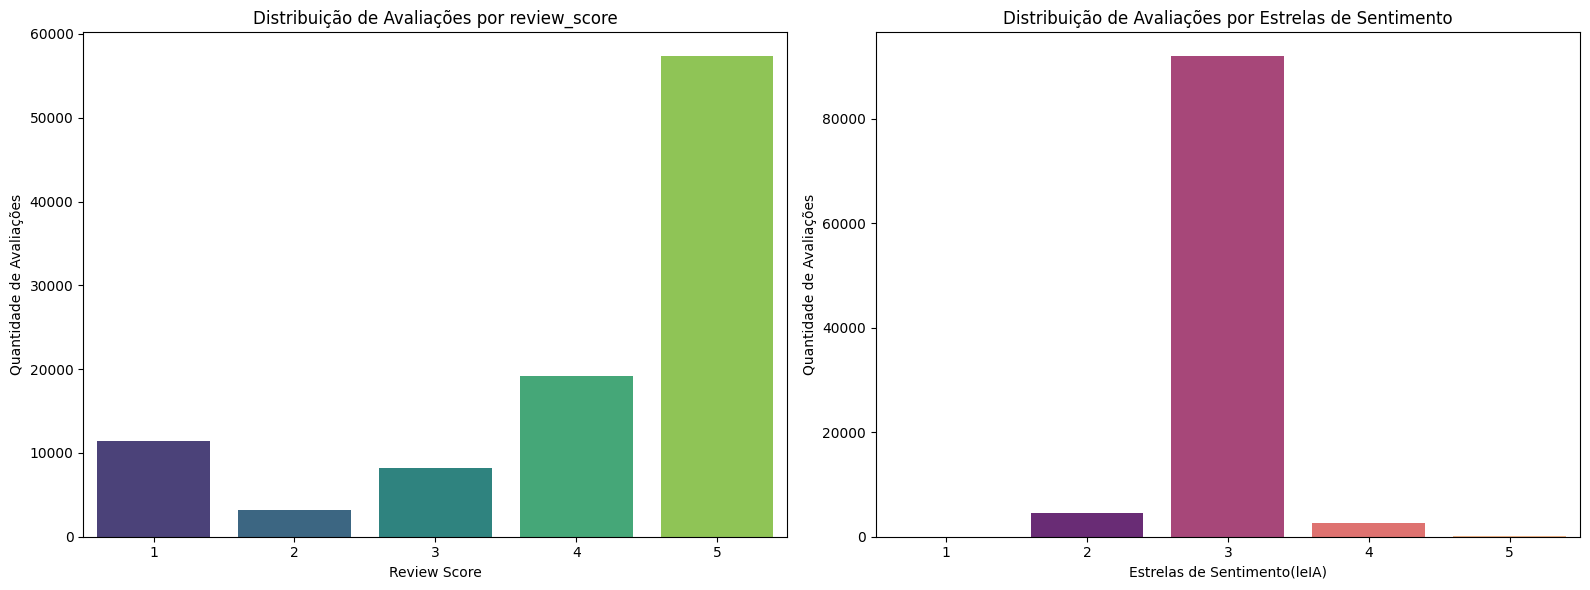

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_avaliacoes, x='review_score', palette='viridis', ax=axes[0])
axes[0].set_title('Distribuição de Avaliações por review_score')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Quantidade de Avaliações')

sns.countplot(data=df_avaliacoes, x='estrelas_sentimento_vader', palette='magma', ax=axes[1])
axes[1].set_title('Distribuição de Avaliações por Estrelas de Sentimento')
axes[1].set_xlabel('Estrelas de Sentimento(leIA)')
axes[1].set_ylabel('Quantidade de Avaliações')

plt.tight_layout()
plt.show()

/tmp/ipykernel_7302/1262993047.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_avaliacoes, x='estrelas_sentimento_vader', palette='viridis', ax=axes[0])
/tmp/ipykernel_7302/1262993047.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_avaliacoes, x='estrelas_sentimento', palette='magma', ax=axes[1])


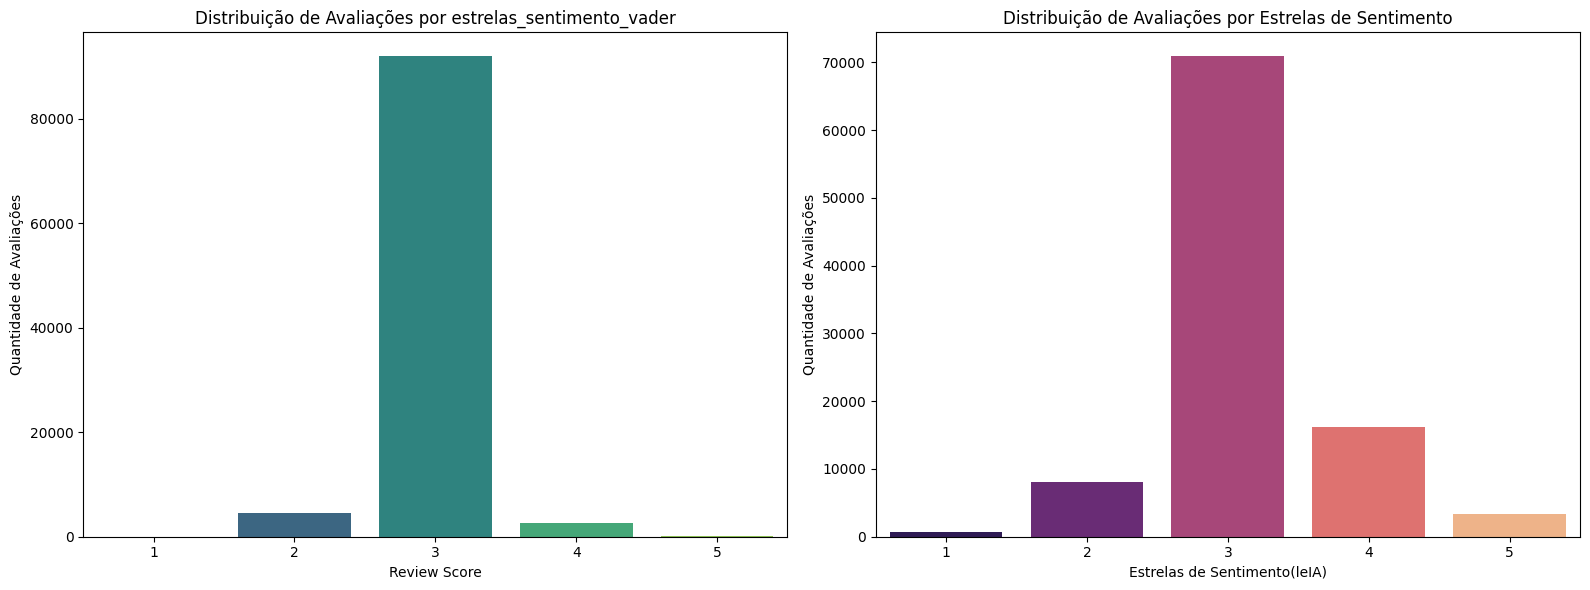

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_avaliacoes, x='estrelas_sentimento_vader', palette='viridis', ax=axes[0])
axes[0].set_title('Distribuição de Avaliações por estrelas_sentimento_vader')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Quantidade de Avaliações')

sns.countplot(data=df_avaliacoes, x='estrelas_sentimento', palette='magma', ax=axes[1])
axes[1].set_title('Distribuição de Avaliações por Estrelas de Sentimento')
axes[1].set_xlabel('Estrelas de Sentimento(leIA)')
axes[1].set_ylabel('Quantidade de Avaliações')

plt.tight_layout()
plt.show()

### ESTRELAS SENTIMENTO X ESTRELAS SENTIMENTO(ONLY EMOJIS)

/tmp/ipykernel_7302/3155130605.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_emoji_reviews, x='estrelas_sentimento', palette='viridis', ax=axes[0])
/tmp/ipykernel_7302/3155130605.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_avaliacoes, x='estrelas_sentimento', palette='magma', ax=axes[1])


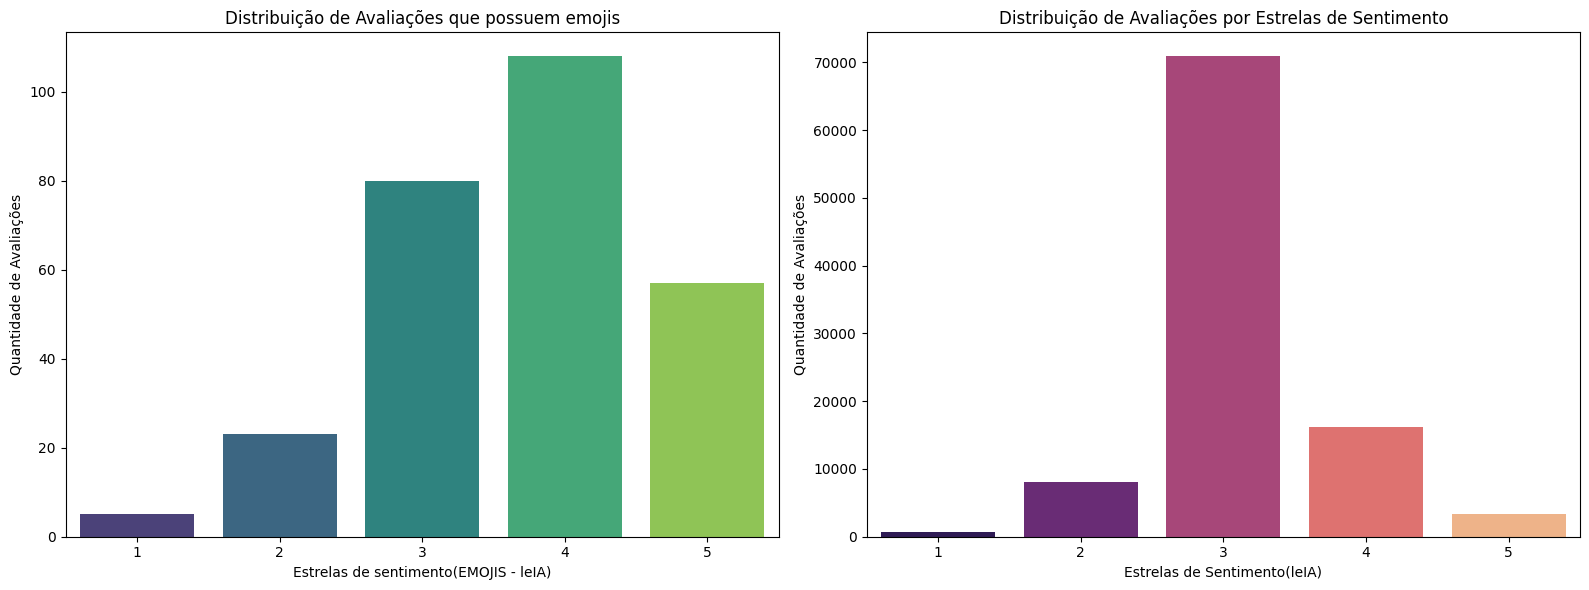

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_emoji_reviews, x='estrelas_sentimento', palette='viridis', ax=axes[0])
axes[0].set_title('Distribuição de Avaliações que possuem emojis')
axes[0].set_xlabel('Estrelas de sentimento(EMOJIS - leIA)')
axes[0].set_ylabel('Quantidade de Avaliações')

sns.countplot(data=df_avaliacoes, x='estrelas_sentimento', palette='magma', ax=axes[1])
axes[1].set_title('Distribuição de Avaliações por Estrelas de Sentimento')
axes[1].set_xlabel('Estrelas de Sentimento(leIA)')
axes[1].set_ylabel('Quantidade de Avaliações')

plt.tight_layout()
plt.show()

### Distribuição de Nº de Caracteres por comentários

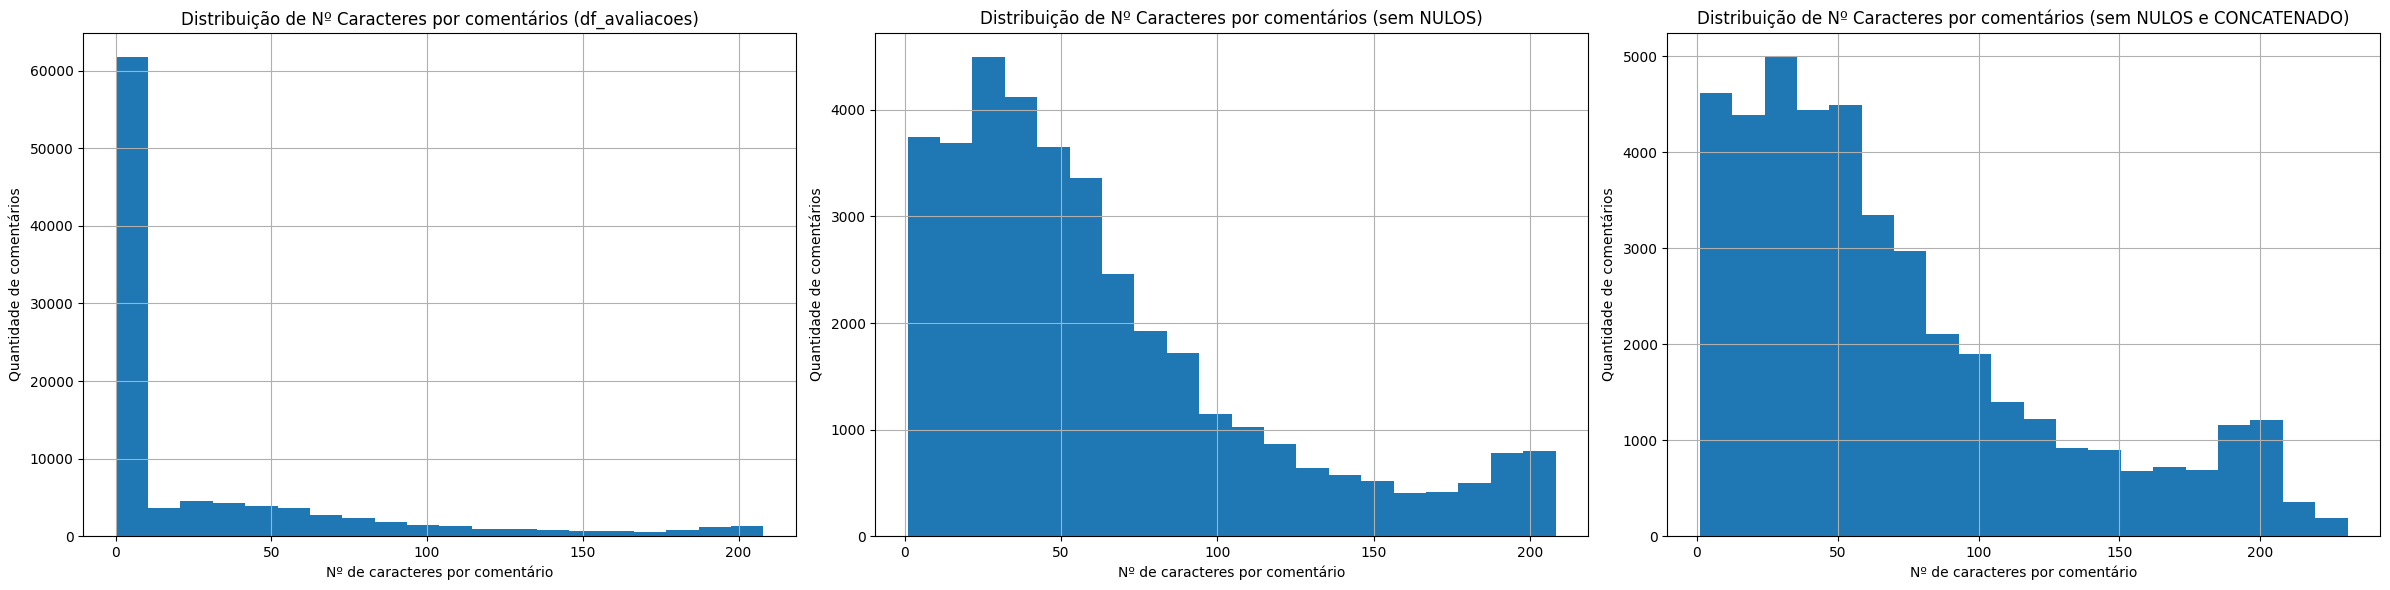

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6)) # 1 linha, 3 colunas

# Gráfico 1: df_avaliacoes
df_avaliacoes["review_message_length"].hist(bins=20, ax=axes[0])
axes[0].set_title("Distribuição de Nº Caracteres por comentários (df_avaliacoes)")
axes[0].set_xlabel("Nº de caracteres por comentário")
axes[0].set_ylabel("Quantidade de comentários")

# Gráfico 2: df_av_sem_nulo
df_av_sem_nulo["review_message_length"].hist(bins=20, ax=axes[1])
axes[1].set_title("Distribuição de Nº Caracteres por comentários (sem NULOS)")
axes[1].set_xlabel("Nº de caracteres por comentário")
axes[1].set_ylabel("Quantidade de comentários")

# Gráfico 3: df_av_concatenado_sem_nulo
df_av_concatenado_sem_nulo["review_message_length"].hist(bins=20, ax=axes[2])
axes[2].set_title("Distribuição de Nº Caracteres por comentários (sem NULOS e CONCATENADO)")
axes[2].set_xlabel("Nº de caracteres por comentário")
axes[2].set_ylabel("Quantidade de comentários")

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

In [ ]:
# NOVA VERIFICAÇÃO TAMANHO DE COMENTÁRIOS POR NÚMERO DE CARACTERES(DF_AV_SEM_NULO)
df_av_sem_nulo["review_message_length"].value_counts()

,count
review_message_length,
9,821
10,585
3,474
26,459
5,454
...,...
202,12
203,11
208,1


In [ ]:
# NOVA VERIFICAÇÃO TAMANHO DE COMENTÁRIOS POR NÚMERO DE CARACTERES(DF_AV_CONCATENADO_SEM_NULO)
df_av_concatenado_sem_nulo["review_message_length"].value_counts()

,count
review_message_length,
9,1211
5,709
3,571
26,478
15,477
...,...
205,14
225,13
231,1


In [ ]:
zip_code_lengths = df_clientes['customer_zip_code_prefix'].astype(str).apply(len)
display(zip_code_lengths.value_counts())

,count
customer_zip_code_prefix,
5,75446
4,23995


In [ ]:
display(df_filtered_non_empty["review_message_length"].value_counts())

,count
review_message_length,
9,837
200,659
10,586
3,475
26,467
...,...
202,14
208,1
205,1


In [ ]:
df_avaliacoes['review_comment_title_length'] = df_avaliacoes['review_comment_title'].astype(str).apply(len)
display(df_avaliacoes['review_comment_title_length'].describe())

,review_comment_title_length
count,99224.000000
mean,4.042853
std,3.593028
min,1.000000
25%,3.000000
50%,3.000000
75%,3.000000
max,26.000000


In [ ]:
display(df_avaliacoes['review_comment_title'])

,review_comment_title
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
99219,NaN
99220,NaN
99221,NaN
99222,NaN


## anotacoes:

- zip_code_prefix deve ter 5 digitos obrigatoriamente, ele representa os primeiros digitos do cep em todas as tabelas, registros com 4 digitos devem ser corrigidos adicionando 1 zero á esquerda para padronização

- descrições e titulos de comentario devem ter o tamanho definido seguindo a média geral deles, o maior valor

In [ ]:
dataframes_to_analyze = {
    "df_avaliacoes": df_avaliacoes,
    "df_clientes": df_clientes,
    "df_vendedores": df_vendedores,
    "df_geolocalizacao": df_geolocalizacao
}

print("--- Quantidade total de registros por DataFrame ---")
for df_name, df in dataframes_to_analyze.items():
    try:
        total_records = df.shape[0]
        print(f"  {df_name}: {total_records} registros")
    except Exception as e:
        print(f"  Erro ao obter o número de registros para {df_name}: {e}")


--- Quantidade total de registros por DataFrame ---
  df_avaliacoes: 99224 registros
  df_clientes: 99441 registros
  df_vendedores: 3095 registros
  df_geolocalizacao: 1000163 registros
